# Mapping Food Access, grocery stores, and Urban Farms

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [11]:
# Converting CSV to GDF

# converting to DF
df = pd.read_csv("Dallas_Data/cleaned_dallas_snap_data.csv")

# to point geometries
geometry = gpd.points_from_xy(df["Longitude"], df["Latitude"])

dallasSNAP = gpd.GeoDataFrame(
    df[["Store_Name", "Store_Street_Address", "City", "Zip_Code", "Store_Type", "Latitude", "Longitude"]], 
    geometry=geometry,
    crs="EPSG:4326"
)

dallasSNAP.head()

,Store_Name,Store_Street_Address,City,Zip_Code,Store_Type,Latitude,Longitude,geometry
0,HEB Food Store 817,2351 W Interstate Highway 635,Irving,75063,Supermarket,32.921303,-96.983322,POINT (-96.98332 32.9213)
1,Homefoods I I I Llc,2301 W Rochelle Rd,Irving,75062,Grocery Store,32.841888,-96.975380,POINT (-96.97538 32.84189)
2,Fair Park Farmers Market,3535 Grand Ave,Dallas,75210,Farmers and Markets,32.778282,-96.763084,POINT (-96.76308 32.77828)
3,Joe V's Smart Shop 805,7700 Samuell Blvd,Dallas,75227,Supermarket,32.792328,-96.685730,POINT (-96.68573 32.79233)
4,Abyssinia Market Irving,4010 N Belt Ln Rd,Irving,75038,Grocery Store,32.867268,-96.981628,POINT (-96.98163 32.86727)


In [21]:
dallasTractIncome = gpd.read_file('food_justice/dallascounty/dallasMedianInc.geojson')

In [22]:
dallasFarms = gpd.read_file('urbanFarmData/dallasFarmsFinal.geojson')

In [23]:
# Converting CRS for accurate distances in meters 
dallasTractIncome = dallasTractIncome.to_crs(epsg=26914)
dallasSNAP = dallasSNAP.to_crs(epsg=26914)
dallasFarms = dallasFarms.to_crs(epsg=26914)

In [26]:
dallasTractIncome.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME_x',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND',
       ...
       'S1903_C03_036M', 'S1903_C03_037E', 'S1903_C03_037M', 'S1903_C03_038E',
       'S1903_C03_038M', 'S1903_C03_039E', 'S1903_C03_039M', 'S1903_C03_040E',
       'S1903_C03_040M', 'geometry'],
      dtype='object', length=256)

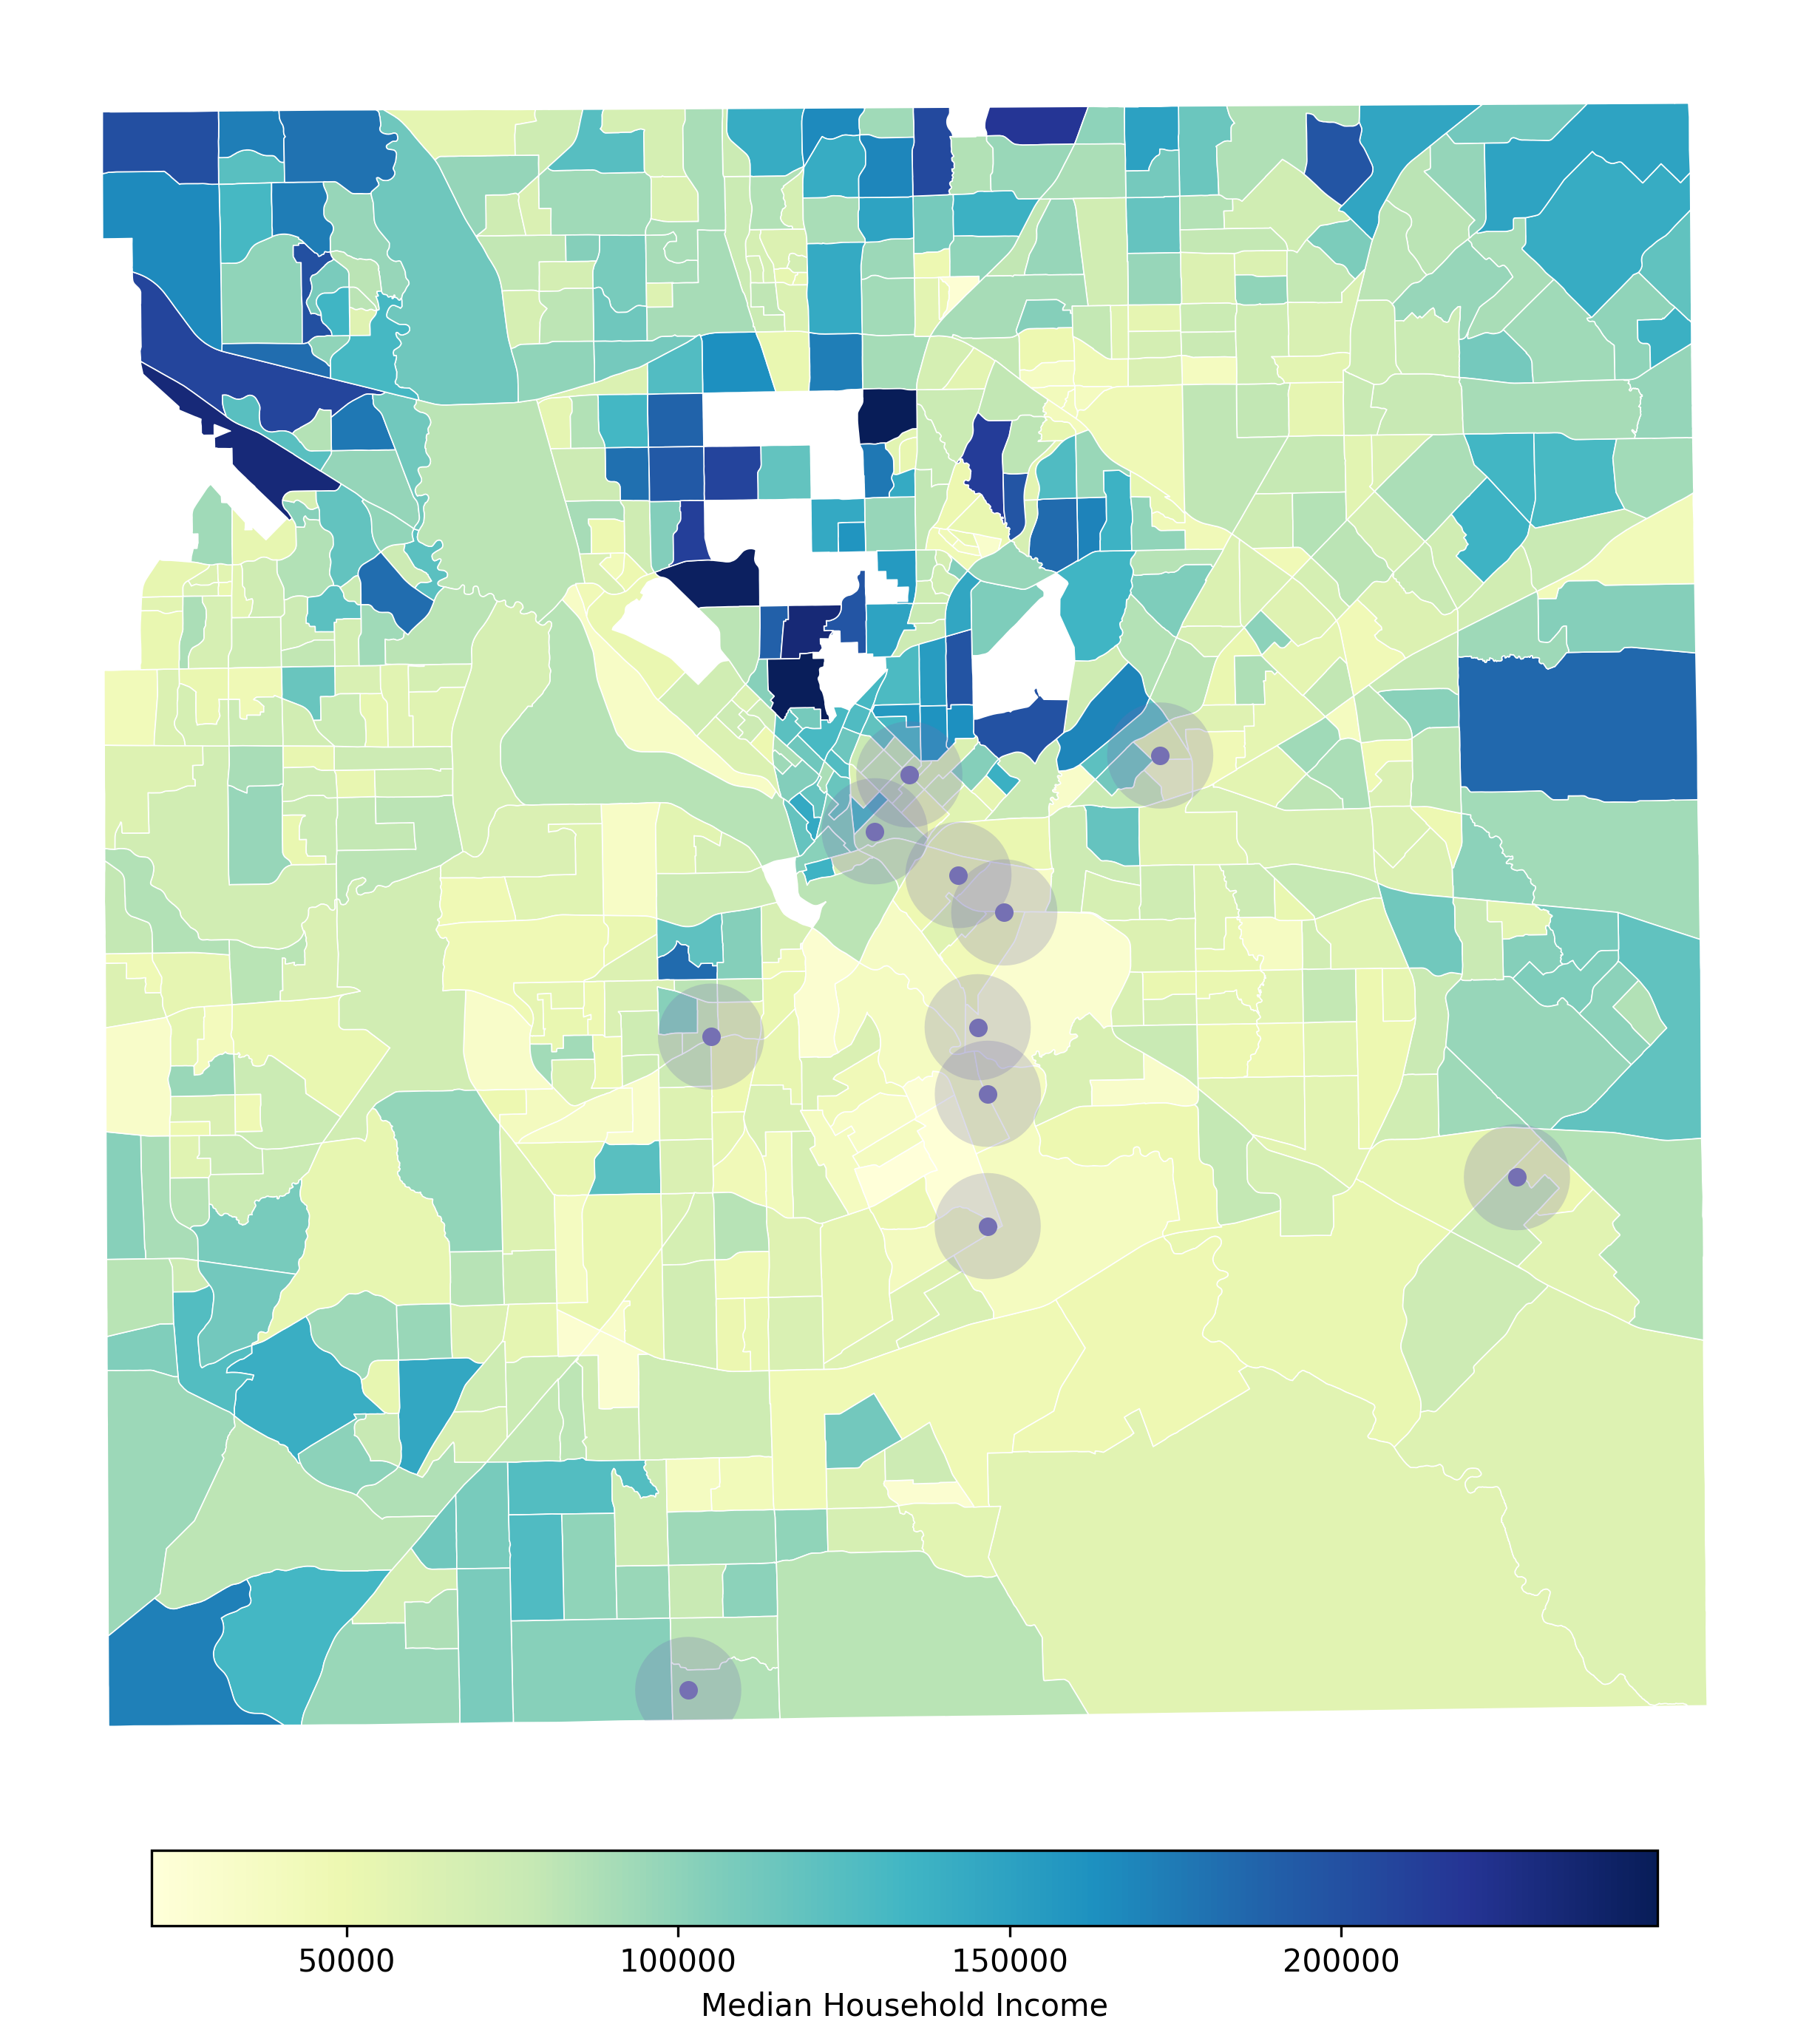

In [45]:
# 2. Dissolve tracts to create a county boundary for clean clipping
county_boundary = dallasTractIncome.union_all()

# 3. Create individual buffers (do NOT dissolve them)
raw_farm_buffers = dallasFarms.buffer(1609.34) # 1-mile radius
farm_buffers_gdf = gpd.GeoDataFrame(geometry=raw_farm_buffers, crs=dallasTractIncome.crs)

# 4. Clip buffers to the county borders
clipped_farm_buffers = gpd.clip(farm_buffers_gdf, county_boundary)

# 5. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

# 6. Plot the Income Choropleth
dallasTractIncome.plot(
    ax=ax,
    column="S1903_C03_001E",
    cmap='YlGnBu',
    edgecolor='#ffffff',
    linewidth=0.4,
    legend=True,
    legend_kwds={
        'label': "Median Household Income",
        'orientation': "horizontal",
        'pad': 0.02,
        'shrink': 0.7
    }
)

# 7. Plot Semi-transparent Buffers with NO outline
# The alpha=0.25 allows overlapping areas to compound and darken naturally
clipped_farm_buffers.plot(
    ax=ax,
    facecolor='#7570b3', # Muted slate/purple
    alpha=0.25,          # Slight transparency
    edgecolor='none',    # Removes the outline
    linewidth=0
)

# 8. Plot Farm Centers as Muted Dots
dallasFarms.plot(
    ax=ax,
    color='#7570b3',     # Matches the muted buffer color
    markersize=25,
    marker='o',          # Circular dots
    zorder=5  
)

# Clean up layout and save
ax.set_axis_off()
plt.tight_layout()
plt.savefig('dallasFarmsIncomeMap.png', dpi=300, bbox_inches='tight')
plt.show()